In [15]:
import snowflake.connector
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Create connection
conn = snowflake.connector.connect(
    user='SHANDEEPRAULA',
    password='Shandeep@200311',
    account='NFBSLVN-YD17402',
    warehouse='COMPUTE_WH',
    database='ECOMMERCE',
    schema='GOLD',
    role='ACCOUNTADMIN'
)

# Create cursor
cur = conn.cursor()

# Query data
query = """
SELECT *
FROM FACT_SESSION
"""

# Load into pandas dataframe
session = pd.read_sql(query, conn)
session.head(2)

,SESSION_ID,CUSTOMER_ID,CHANNEL_ID,SESSION_DATE,DEVICE_TYPE,PAGE_VIEWS,PRODUCT_VIEWS,ADD_TO_CART_COUNT,WISHLIST_ADDITIONS,SEARCH_COUNT,CHECKOUT_ATTEMPTS,PURCHASES,EXIT_PAGE_TYPE,SESSION_DURATION_IN_SEC,ENGAGEMENT_LEVEL,IS_CONVERTED,ADD_TO_CART_RATE,CHECKOUT_CONVERSION_RATE
0,SES000325391,CUST089160,CHN009,2025-05-17T00:00:00.000Z,MOBILE,4.0,4.0,4.0,1.0,6.0,1.0,1.0,CHECKOUT,2933.4,MEDIUM,1,1.0,1.0
1,SES000408697,CUST074829,CHN001,2025-05-17T00:00:00.000Z,MOBILE,50.0,19.0,2.0,2.0,5.0,0.0,0.0,PRODUCT,444.2,LOW,0,0.1,0.0


In [4]:
# Columns & datatype
session.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 18 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   SESSION_ID                1048575 non-null  object 
 1   CUSTOMER_ID               1048575 non-null  object 
 2   CHANNEL_ID                1048575 non-null  object 
 3   SESSION_DATE              1048575 non-null  object 
 4   DEVICE_TYPE               1048575 non-null  object 
 5   PAGE_VIEWS                1048575 non-null  float64
 6   PRODUCT_VIEWS             1048575 non-null  float64
 7   ADD_TO_CART_COUNT         1048575 non-null  float64
 8   WISHLIST_ADDITIONS        1048575 non-null  float64
 9   SEARCH_COUNT              1048575 non-null  float64
 10  CHECKOUT_ATTEMPTS         1048575 non-null  float64
 11  PURCHASES                 1048575 non-null  float64
 12  EXIT_PAGE_TYPE            1048575 non-null  object 
 13  SESSION_DURATION_IN_SEC   1

In [5]:
# Missing values
session.isnull().sum()

SESSION_ID                  0
CUSTOMER_ID                 0
CHANNEL_ID                  0
SESSION_DATE                0
DEVICE_TYPE                 0
PAGE_VIEWS                  0
PRODUCT_VIEWS               0
ADD_TO_CART_COUNT           0
WISHLIST_ADDITIONS          0
SEARCH_COUNT                0
CHECKOUT_ATTEMPTS           0
PURCHASES                   0
EXIT_PAGE_TYPE              0
SESSION_DURATION_IN_SEC     0
ENGAGEMENT_LEVEL            0
IS_CONVERTED                0
ADD_TO_CART_RATE            0
CHECKOUT_CONVERSION_RATE    0
dtype: int64

In [6]:
# Summary stats
session.describe()

,PAGE_VIEWS,PRODUCT_VIEWS,ADD_TO_CART_COUNT,WISHLIST_ADDITIONS,SEARCH_COUNT,CHECKOUT_ATTEMPTS,PURCHASES,SESSION_DURATION_IN_SEC,IS_CONVERTED,ADD_TO_CART_RATE,CHECKOUT_CONVERSION_RATE
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2.551839e+01,8.363125e+00,4.700917e+00,1.998805e+00,4.496637e+00,8.736171e-01,1.000186e+00,3.618308e+03,6.672236e-01,9.004286e-01,6.422583e-01
std,1.442516e+01,5.548553e+00,3.100745e+00,1.414696e+00,2.874265e+00,8.027194e-01,8.159285e-01,2.069699e+03,4.712075e-01,1.340340e+00,5.486282e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.002000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.300000e+01,4.000000e+00,2.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,1.827225e+03,0.000000e+00,2.000000e-01,0.000000e+00
50%,2.600000e+01,8.000000e+00,5.000000e+00,2.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,3.618110e+03,1.000000e+00,5.000000e-01,1.000000e+00
75%,3.800000e+01,1.300000e+01,7.000000e+00,3.000000e+00,7.000000e+00,2.000000e+00,2.000000e+00,5.408800e+03,1.000000e+00,1.000000e+00,1.000000e+00
max,5.000000e+01,1.900000e+01,1.000000e+01,4.000000e+00,9.000000e+00,2.000000e+00,2.000000e+00,7.200000e+03,1.000000e+00,1.000000e+01,2.000000e+00


Matplotlib is building the font cache; this may take a moment.


<Axes: ylabel='count'>

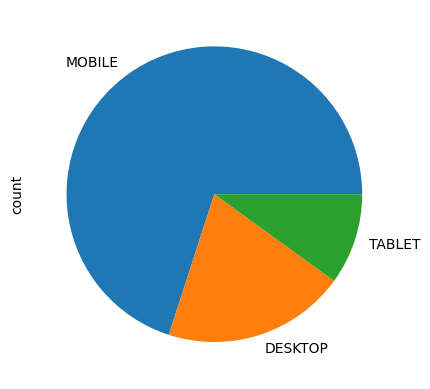

In [13]:
# Device type distribution
session['DEVICE_TYPE'].value_counts().plot(kind='pie')

In [12]:
# Exit Page Types
session['EXIT_PAGE_TYPE'].value_counts()

EXIT_PAGE_TYPE
SEARCH      175510
CART        175198
CHECKOUT    175017
HOME        174617
CATEGORY    174510
PRODUCT     173723
Name: count, dtype: int64

In [ ]:
# Session duration
session['SESSION_DURATION_IN_SEC'].describe()

In [ ]:
# Converted users
session['IS_CONVERTED'].value_counts()

In [10]:
# Conversion rate %
session['IS_CONVERTED'].mean() * 100

np.float64(66.72236129985933)